# 1. Import Libraries

In [38]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import  train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import warnings
warnings.filterwarnings("ignore")

# 2. Load the dataset

In [39]:
df=pd.read_csv("TCS_stock_history.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


# 3. Understand the data

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4463 non-null   object 
 1   Open          4463 non-null   float64
 2   High          4463 non-null   float64
 3   Low           4463 non-null   float64
 4   Close         4463 non-null   float64
 5   Volume        4463 non-null   int64  
 6   Dividends     4463 non-null   float64
 7   Stock Splits  4463 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 279.1+ KB


In [41]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,4463.000000,4463.000000,4463.000000,4463.000000,4.463000e+03,4463.000000,4463.000000
mean,866.936239,876.675013,856.653850,866.537398,3.537876e+06,0.071533,0.001344
std,829.905368,838.267104,821.233477,829.611313,3.273531e+06,0.965401,0.051842
min,24.146938,27.102587,24.146938,26.377609,0.000000e+00,0.000000,0.000000
25%,188.951782,191.571816,185.979417,188.594620,1.860959e+06,0.000000,0.000000
50%,530.907530,534.751639,525.616849,529.713257,2.757742e+06,0.000000,0.000000
75%,1156.462421,1165.815854,1143.622800,1154.784851,4.278625e+06,0.000000,0.000000
max,3930.000000,3981.750000,3892.100098,3954.550049,8.806715e+07,40.000000,2.000000


# 4. Date formatting & sorting

In [42]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

df.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


# 5.Check & handle missing values

In [43]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [44]:
df.fillna(method='ffill', inplace=True)


# 6. Exploratory Data Analysis (EDA)

#### Close Price Trend

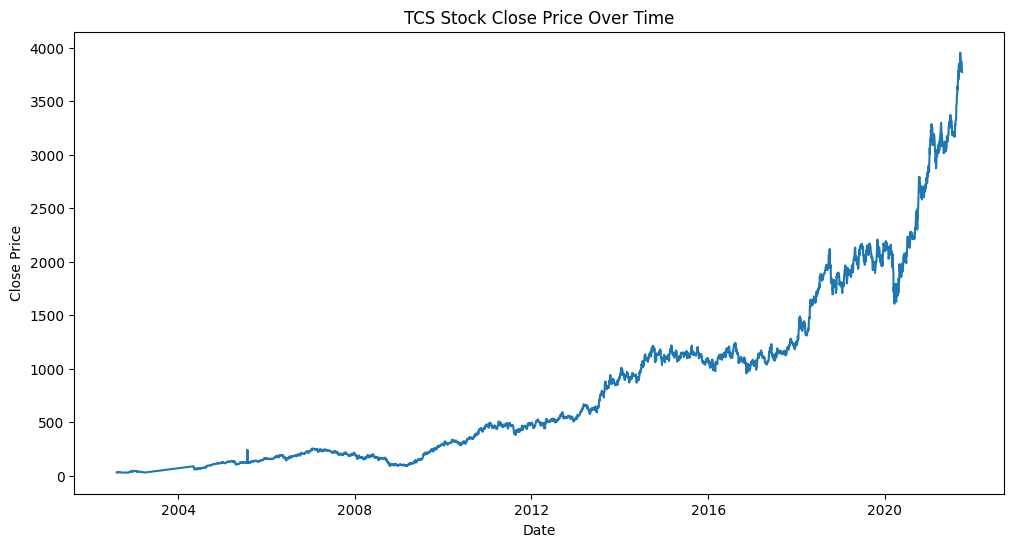

In [45]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("TCS Stock Close Price Over Time")
plt.show()


#### Volume, Dividends, Stock Splits

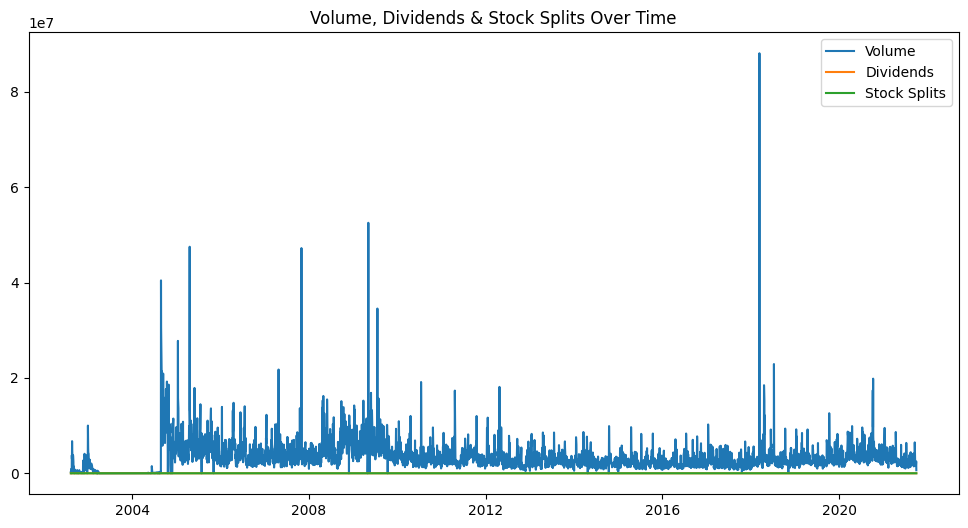

In [46]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volume'], label='Volume')
plt.plot(df['Date'], df['Dividends'], label='Dividends')
plt.plot(df['Date'], df['Stock Splits'], label='Stock Splits')
plt.legend()
plt.title("Volume, Dividends & Stock Splits Over Time")
plt.show()


#### Correlation Heatmap

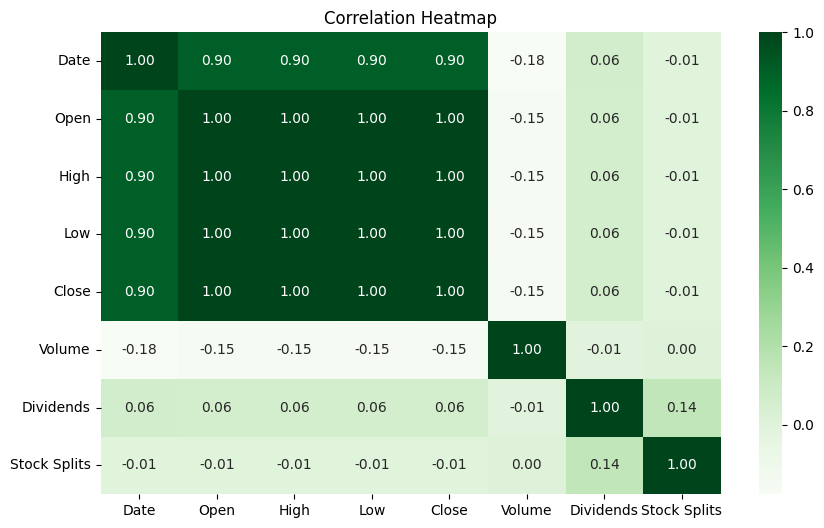

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="Greens", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


#### Close price vs Volume

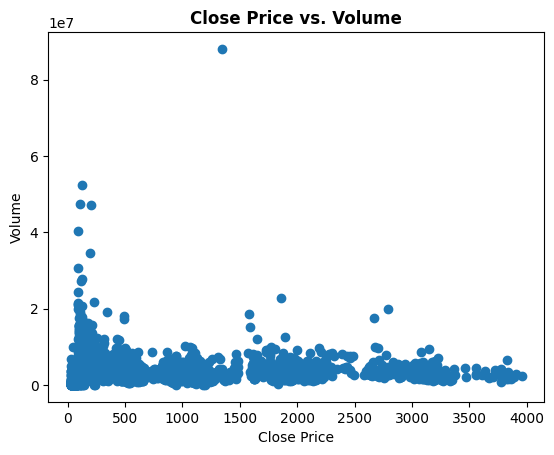

In [48]:
plt.scatter(df['Close'], df['Volume'])
plt.xlabel('Close Price')
plt.ylabel('Volume')
plt.title('Close Price vs. Volume',weight= "bold")
plt.show()

####  50-day and 200-day moving averages

In [49]:
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

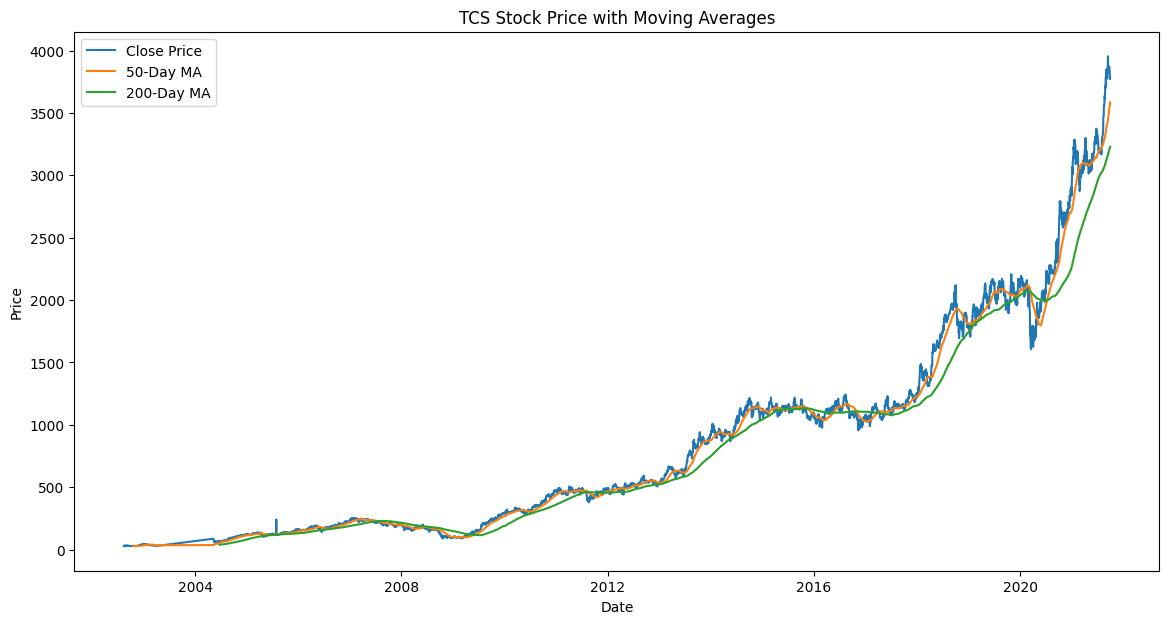

In [50]:
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA50'], label='50-Day MA')
plt.plot(df['Date'], df['MA200'], label='200-Day MA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('TCS Stock Price with Moving Averages')
plt.legend()
plt.show()

# 7.Feature Engineering

In [51]:
# Extract features like Year, Month, Day, Day of Week from Date
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day
df['Day_of_week']=df['Date'].dt.dayofweek



In [52]:
# Lag Features
df['Prev_Close'] = df['Close'].shift(1)
df.dropna(inplace=True) 

# 8. Machine Learning Model(Linear Regeession)

#### Feature & target Selection

In [53]:
X = df[['Open', 'High', 'Low', 'Volume', 'Prev_Close']]
y = df['Close']


#### Train–Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#### Train the Model

In [55]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Prediction & Evaluation

In [56]:
y_pred = lr_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 39.01273869785243
R2 Score: 0.9999438891493312


#### Actual vs Predicted Plot

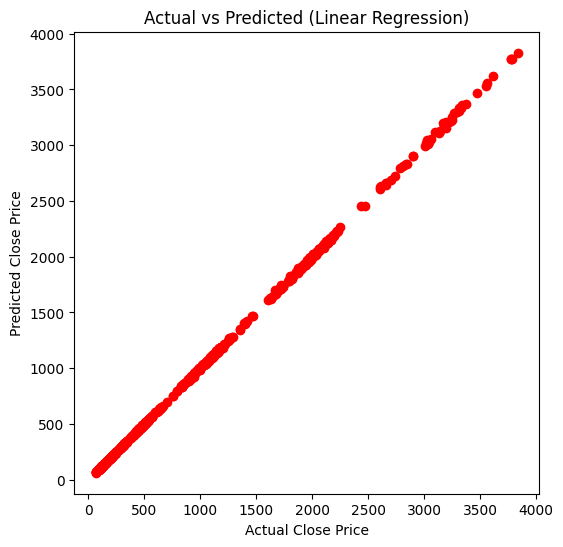

In [57]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred,color='red')
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()


# 9. Deep Learning Model- LSTM(Long Short term Memory)

#### Prepare Data

In [58]:
close_data=df[['Close']].values

#### Scale the data

In [61]:
scaler = MinMaxScaler()
scaled_close = scaler.fit_transform(close_data)


#### Create sequences

In [64]:
X_lstm = []
y_lstm = []

for i in range(1, len(scaled_close)):
    X_lstm.append(scaled_close[i-1:i])
    y_lstm.append(scaled_close[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)


#### Train–Test Split (Time Series)

In [65]:
split = int(0.8 * len(X_lstm))
X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]


#### Build LSTM Model

In [66]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(X_train_lstm.shape[1], 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')


#### Train LSTM Model

In [67]:
lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=16
)


Epoch 1/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0079
Epoch 2/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.0079e-04
Epoch 3/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0477e-05
Epoch 4/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0552e-05
Epoch 5/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0457e-05
Epoch 6/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0568e-05
Epoch 7/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0330e-05
Epoch 8/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0026e-05
Epoch 9/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0152e-05
Epoch 10/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0545e-05
Epoch 11/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.8718e-06
Epoch 12/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.7255e-06
Epoch 13/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.4325e-06
Epoch 14/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.5654e-06
Epoch

#### Predict & Inverse Transform

In [68]:
lstm_predictions = lstm_model.predict(X_test_lstm)

lstm_predictions = scaler.inverse_transform(lstm_predictions)
actual_prices = scaler.inverse_transform(y_test_lstm)


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


#### LSTM Evaluation

In [69]:
mae = mean_absolute_error(actual_prices, lstm_predictions)
print("LSTM Mean Absolute Error:", mae)


LSTM Mean Absolute Error: 32.83632718049348


#### Actual vs Predicted Plot (LSTM)

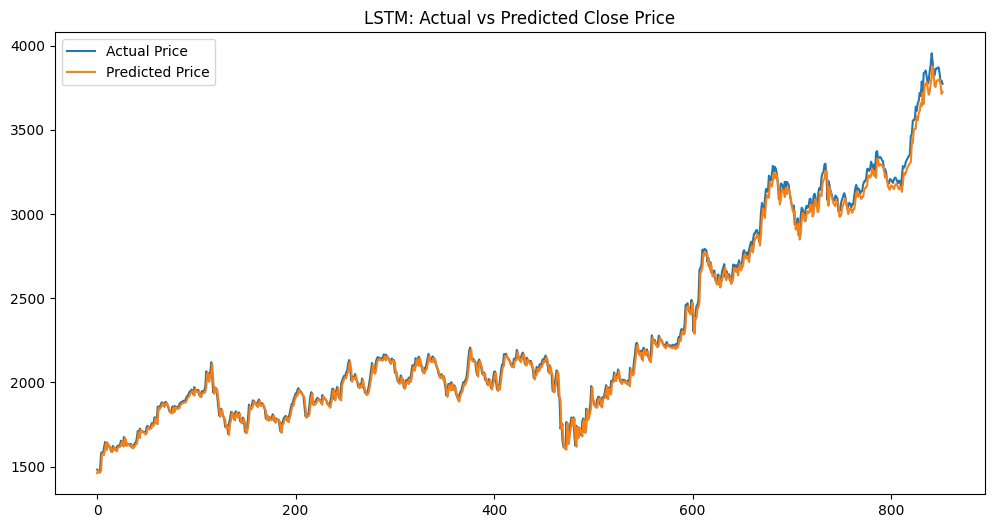

In [70]:
plt.figure(figsize=(12,6))
plt.plot(actual_prices, label="Actual Price")
plt.plot(lstm_predictions, label="Predicted Price")
plt.legend()
plt.title("LSTM: Actual vs Predicted Close Price")
plt.show()


# 10. Save Prdictions

In [71]:
pred_df = pd.DataFrame({
    "Actual_Close": actual_prices.flatten(),
    "Predicted_Close": lstm_predictions.flatten()
})

pred_df.to_csv("tcs_lstm_predictions.csv", index=False)
